mengimport library dan model yang digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

membaca dataset

In [2]:
data = pd.read_csv("dataset_radiasi_surya_indonesia.csv")

nama_kolom_baru = {
    "date": "tanggal",
    "ghi_kwh_m2_day": "radiasi_matahari",
    "temp_2m_c": "suhu_udara_c",
    "humidity_2m_pct": "kelembapan_persen",
    "wind_2m_ms": "kecepatan_angin_ms",
    "rain_mm_day": "curah_hujan_mm",
    "cloud_pct": "tutupan_awan_persen",
    "location": "kota",
    "latitude": "lintang",
    "longitude": "bujur",
    "day_of_year": "hari_ke",
    "month": "bulan",
}
data = data.rename(columns=nama_kolom_baru)

KOLOM_TARGET = "radiasi_matahari"
data["tanggal"] = pd.to_datetime(data["tanggal"], errors="raise")

print("Sumber data: NASA POWER Daily API")
print("Ukuran dataset:", data.shape)
print(data.head())


Sumber data: NASA POWER Daily API
Ukuran dataset: (62101, 12)
     tanggal  radiasi_matahari  suhu_udara_c  kelembapan_persen  \
0 2015-01-01            4.8521         26.94              88.09   
1 2015-01-02            3.5474         26.64              90.19   
2 2015-01-03            3.6610         26.33              89.65   
3 2015-01-04            3.3674         26.25              88.58   
4 2015-01-05            4.7297         26.64              87.25   

   kecepatan_angin_ms  curah_hujan_mm  tutupan_awan_persen   kota  lintang  \
0                2.48            4.10                98.44  Ambon     -3.7   
1                2.57            9.45                98.03  Ambon     -3.7   
2                2.99           10.29                99.76  Ambon     -3.7   
3                2.76            6.80                99.52  Ambon     -3.7   
4                2.74            6.98                99.13  Ambon     -3.7   

    bujur  hari_ke  bulan  
0  128.18        1      1  
1  128.18 

cleaning dan preprocesing dataa

In [3]:
data.columns = data.columns.str.strip()
data = data.replace(-999, np.nan)
data["tanggal"] = pd.to_datetime(data["tanggal"], errors="coerce")
data = data.drop_duplicates(["kota", "tanggal"])

kolom_wajib = [
    "tanggal", "kota", "lintang", "bujur", KOLOM_TARGET,
    "suhu_udara_c", "kelembapan_persen", "kecepatan_angin_ms", "tutupan_awan_persen"
]

data = data.dropna(subset=kolom_wajib).copy()

print("Ukuran setelah cleaning:", data.shape)
print("Jumlah kota:", data["kota"].nunique())
print("Rentang tanggal:", data["tanggal"].min().date(), "s.d.", data["tanggal"].max().date())
print("Data kosong:\n", data[kolom_wajib].isna().sum())
print("Data hujan di atas 100 mm/hari:", (data["curah_hujan_mm"] > 100).sum())

Ukuran setelah cleaning: (62101, 12)
Jumlah kota: 17
Rentang tanggal: 2015-01-01 s.d. 2024-12-31
Data kosong:
 tanggal                0
kota                   0
lintang                0
bujur                  0
radiasi_matahari       0
suhu_udara_c           0
kelembapan_persen      0
kecepatan_angin_ms     0
tutupan_awan_persen    0
dtype: int64
Data hujan di atas 100 mm/hari: 65


membuat grafik visual GHI

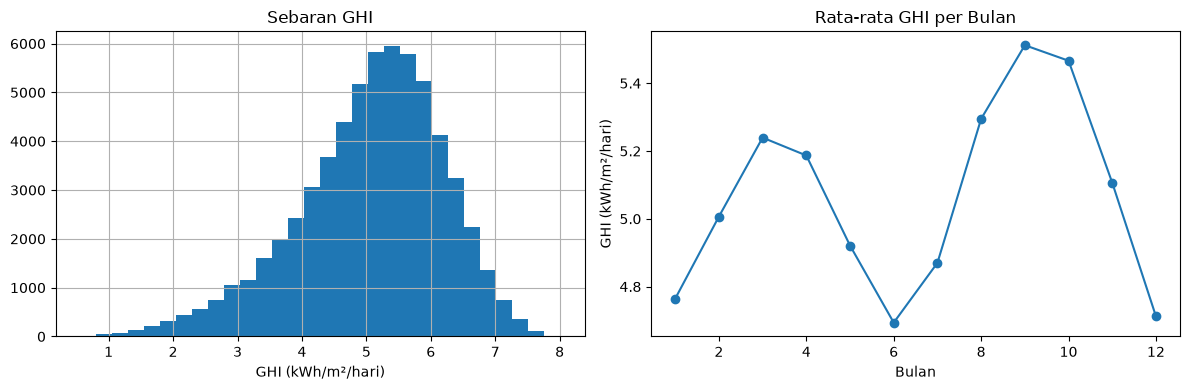

kota
Kupang            5.913175
Denpasar          5.580216
Manado            5.402985
Makassar          5.380249
Surabaya          5.203838
Semarang          5.128129
Pontianak         5.118954
Bandar Lampung    5.047508
Banda Aceh        5.005788
Ambon             4.960574
Banjarmasin       4.915281
Jayapura          4.903090
Samarinda         4.754011
Jakarta           4.744649
Medan             4.720158
Padang            4.689924
Palembang         4.625630
Name: radiasi_matahari, dtype: float64


In [4]:
gambar, sumbu = plt.subplots(1, 2, figsize=(12, 4))

data[KOLOM_TARGET].hist(bins=30, ax=sumbu[0])
sumbu[0].set_title("Sebaran GHI")
sumbu[0].set_xlabel("GHI (kWh/m²/hari)")

data.groupby(data["tanggal"].dt.month)[KOLOM_TARGET].mean().plot(ax=sumbu[1], marker="o")
sumbu[1].set_title("Rata-rata GHI per Bulan")
sumbu[1].set_xlabel("Bulan")
sumbu[1].set_ylabel("GHI (kWh/m²/hari)")

plt.tight_layout()
plt.show()

print(data.groupby("kota")[KOLOM_TARGET].mean().sort_values(ascending=False))

menambahkan fitur 

In [5]:
data["bulan"] = data["tanggal"].dt.month
hari_dalam_tahun = data["tanggal"].dt.dayofyear

data["musim_sin"] = np.sin(2 * np.pi * hari_dalam_tahun / 365.25)
data["musim_cos"] = np.cos(2 * np.pi * hari_dalam_tahun / 365.25)

DAFTAR_FITUR = [
    "suhu_udara_c",
    "kelembapan_persen",
    "kecepatan_angin_ms",
    "tutupan_awan_persen",
    "lintang",
    "bujur",
    "musim_sin",
    "musim_cos"
]

print("Target:", KOLOM_TARGET)
print("Fitur:", DAFTAR_FITUR)

Target: radiasi_matahari
Fitur: ['suhu_udara_c', 'kelembapan_persen', 'kecepatan_angin_ms', 'tutupan_awan_persen', 'lintang', 'bujur', 'musim_sin', 'musim_cos']


membagi data latih dan data testing

In [6]:
data_latih = data[data["tanggal"] < "2023-01-01"]
data_uji = data[data["tanggal"] >= "2023-01-01"]

X_latih = data_latih[DAFTAR_FITUR]
y_latih = data_latih[KOLOM_TARGET]

X_uji = data_uji[DAFTAR_FITUR]
y_uji = data_uji[KOLOM_TARGET]

print("Data training:", len(data_latih), "baris")
print("Periode training:", data_latih["tanggal"].min().date(), "s.d.", data_latih["tanggal"].max().date())
print("Data testing:", len(data_uji), "baris")
print("Periode testing:", data_uji["tanggal"].min().date(), "s.d.", data_uji["tanggal"].max().date())

Data training: 49674 baris
Periode training: 2015-01-01 s.d. 2022-12-31
Data testing: 12427 baris
Periode testing: 2023-01-01 s.d. 2024-12-31


memuat model random forest regresor

In [7]:
model_rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_latih, y_latih)

prediksi_uji = np.maximum(model_rf.predict(X_uji), 0)

print("Model Random Forest selesai dilatih.")

Model Random Forest selesai dilatih.


mengevaluasi model

In [8]:
nilai_mae = mean_absolute_error(y_uji, prediksi_uji)
nilai_rmse = np.sqrt(mean_squared_error(y_uji, prediksi_uji))
nilai_r2 = r2_score(y_uji, prediksi_uji)

print(f"MAE:  {nilai_mae:.3f} kWh/m²/hari")
print(f"RMSE: {nilai_rmse:.3f} kWh/m²/hari")
print(f"R²:   {nilai_r2:.3f}")

MAE:  0.445 kWh/m²/hari
RMSE: 0.629 kWh/m²/hari
R²:   0.698


bandngkan rata rata GHI/ kota


In [9]:
hasil_kota = data_uji[["kota", KOLOM_TARGET]].copy()
hasil_kota["radiasi_prediksi"] = prediksi_uji

peringkat_kota = (
    hasil_kota.groupby("kota")
    .agg(
        radiasi_acuan=(KOLOM_TARGET, "mean"),
        radiasi_prediksi=("radiasi_prediksi", "mean")
    )
)

peringkat_kota["peringkat_acuan"] = (
    peringkat_kota["radiasi_acuan"]
    .rank(ascending=False, method="min")
    .astype(int)
)

peringkat_kota["peringkat_prediksi"] = (
    peringkat_kota["radiasi_prediksi"]
    .rank(ascending=False, method="min")
    .astype(int)
)

peringkat_kota = peringkat_kota.sort_values("radiasi_prediksi", ascending=False)

print(peringkat_kota.round(3))

kemiripan_peringkat = peringkat_kota[
    ["peringkat_acuan", "peringkat_prediksi"]
].corr(method="spearman").iloc[0, 1]

print("\nKemiripan urutan peringkat kota:", round(kemiripan_peringkat, 3))


                radiasi_acuan  radiasi_prediksi  peringkat_acuan  \
kota                                                               
Kupang                  5.865             5.948                1   
Denpasar                5.616             5.649                2   
Makassar                5.375             5.452                4   
Surabaya                5.231             5.411                5   
Manado                  5.392             5.391                3   
Semarang                5.220             5.231                6   
Banda Aceh              5.053             5.208                9   
Pontianak               5.136             5.140                7   
Bandar Lampung          5.088             5.113                8   
Banjarmasin             4.981             5.094               10   
Ambon                   4.905             5.000               11   
Jakarta                 4.730             4.970               14   
Jayapura                4.813             4.883 

Gambarkan perbandingan rata-rata kota

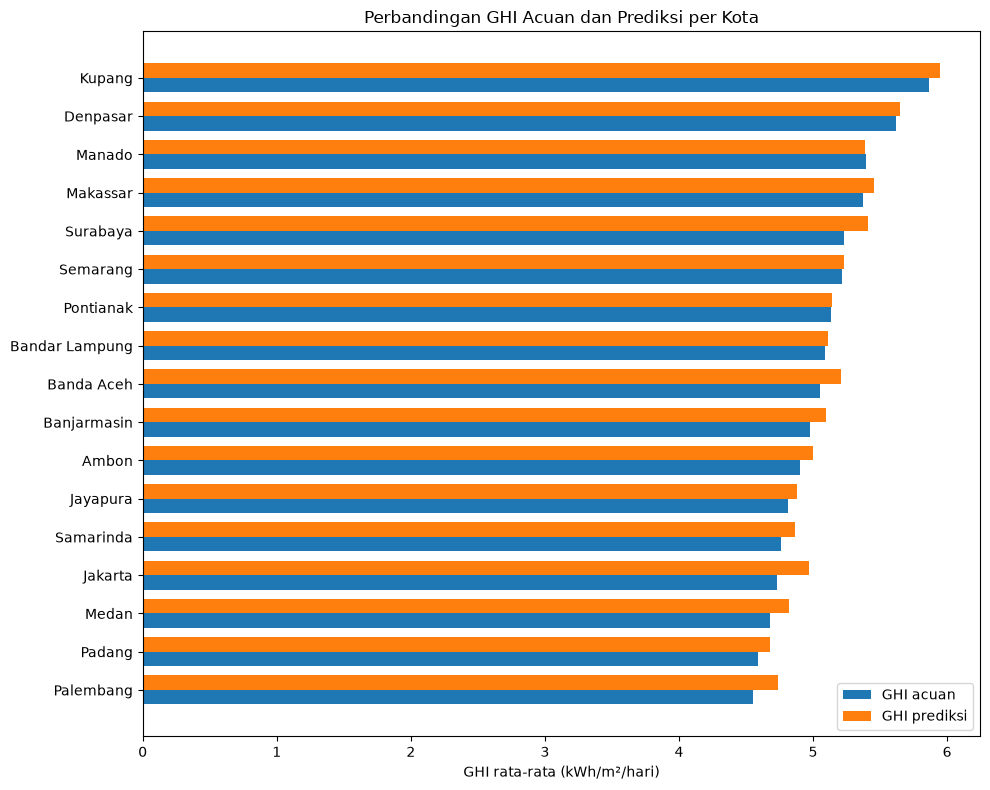

In [10]:
grafik_kota = peringkat_kota.sort_values("radiasi_acuan")

posisi = np.arange(len(grafik_kota))
tinggi_batang = 0.38

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    posisi - tinggi_batang / 2,
    grafik_kota["radiasi_acuan"],
    tinggi_batang,
    label="GHI acuan"
)

ax.barh(
    posisi + tinggi_batang / 2,
    grafik_kota["radiasi_prediksi"],
    tinggi_batang,
    label="GHI prediksi"
)

ax.set_yticks(posisi)
ax.set_yticklabels(grafik_kota.index)
ax.set_xlabel("GHI rata-rata (kWh/m²/hari)")
ax.set_title("Perbandingan GHI Acuan dan Prediksi per Kota")
ax.legend()
plt.tight_layout()
plt.show()


Lihat fitur yang paling berpengaruh pada Random Forest

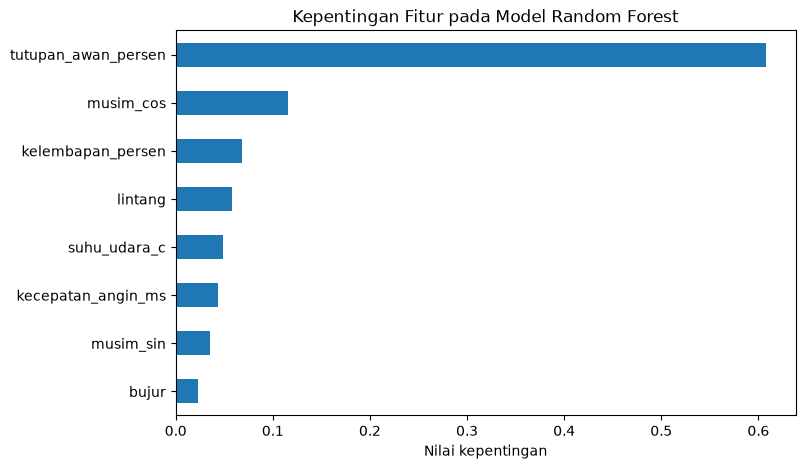

tutupan_awan_persen    0.608
musim_cos              0.115
kelembapan_persen      0.069
lintang                0.058
suhu_udara_c           0.048
kecepatan_angin_ms     0.043
musim_sin              0.035
bujur                  0.023
dtype: float64


In [11]:
kepentingan_fitur = pd.Series(
    model_rf.feature_importances_,
    index=DAFTAR_FITUR
).sort_values()

kepentingan_fitur.plot(kind="barh", figsize=(8, 5))
plt.title("Kepentingan Fitur pada Model Random Forest")
plt.xlabel("Nilai kepentingan")
plt.show()

print(kepentingan_fitur.sort_values(ascending=False).round(3))


Siapkan model final untuk input pengguna

In [16]:
model_final = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model_final.fit(data[DAFTAR_FITUR], data[KOLOM_TARGET])

koordinat_kota = (
    data[["kota", "lintang", "bujur"]]
    .drop_duplicates("kota")
    .set_index("kota")
)

print("Model final siap digunakan.")
print("Kota yang tersedia:")
print(", ".join(sorted(koordinat_kota.index)))


Model final siap digunakan.
Kota yang tersedia:
Ambon, Banda Aceh, Bandar Lampung, Banjarmasin, Denpasar, Jakarta, Jayapura, Kupang, Makassar, Manado, Medan, Padang, Palembang, Pontianak, Samarinda, Semarang, Surabaya
